# Callback-Pool Queueing Model: Sensitivity Experiments

This notebook reproduces the sensitivity analysis experiments from the paper, comparing:
- **CE** (Correlated Equilibrium with message-contingent obedience)
- **CCE** (Coarse Correlated Equilibrium with ex ante obedience)
- **Selfish FI** (Full-information observable benchmark)

We analyze how welfare and action frequencies vary with:
1. **ρ = λ/μ** (traffic intensity)
2. **γ** (callback intensity)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pulp as pl

# Import core algorithms
from algorithms import selfish_FI_observable, fixed_point_solve_CE_CCE

# Import utilities
from utils import metrics_from_solution, plot_three_curves

## Helper Function: Run Sensitivity Sweep

In [2]:
def run_sweep(
    x_grid,
    build_params_at_x,
    xlabel,
    base_params,
    N=15,
    M=10,
    fp_max_iter=150,
    fp_tol=1e-6,
    fp_damping=0.2,
):
    """
    Run a parameter sweep comparing CE, CCE, and Selfish FI.
    
    Parameters:
    -----------
    x_grid : array-like
        Grid of parameter values to sweep over
    build_params_at_x : callable
        Function that takes x and returns dict of params to update
    xlabel : str
        Label for x-axis
    base_params : dict
        Base parameters (mu, gamma, R, C, rD, Cd)
    N : int
        Truncation level for in-system occupancy
    M : int
        Truncation level for callback pool size
    fp_max_iter : int
        Maximum fixed-point iterations
    fp_tol : float
        Convergence tolerance
    fp_damping : float
        Damping factor
    """
    solver = pl.PULP_CBC_CMD(msg=False)

    y_ce_w, y_cce_w, y_fi_w = [], [], []
    y_ce_pJ, y_cce_pJ, y_fi_pJ = [], [], []
    y_ce_pD, y_cce_pD, y_fi_pD = [], [], []
    y_ce_pB, y_cce_pB, y_fi_pB = [], [], []

    warm_ce = None
    warm_cce = None

    for x in x_grid:
        p = dict(base_params)
        p.update(build_params_at_x(x))

        # Solve Selfish FI
        fi = selfish_FI_observable(
            lam=p["lam"], mu=p["mu"], gamma=p["gamma"], N=N, M=M,
            R=p["R"], C=p["C"], rD=p["rD"], Cd=p["Cd"],
        )

        # Solve CE
        sol_ce = fixed_point_solve_CE_CCE(
            mode="CE",
            lam=p["lam"], mu=p["mu"], gamma=p["gamma"], N=N, M=M,
            R=p["R"], C=p["C"], rD=p["rD"], Cd=p["Cd"],
            max_iter=fp_max_iter, tol=fp_tol, damping=fp_damping,
            solver=solver,
            warm_start=warm_ce
        )
        ce = metrics_from_solution(sol_ce)
        warm_ce = sol_ce["uD_endogenous"]

        # Solve CCE
        sol_cce = fixed_point_solve_CE_CCE(
            mode="CCE",
            lam=p["lam"], mu=p["mu"], gamma=p["gamma"], N=N, M=M,
            R=p["R"], C=p["C"], rD=p["rD"], Cd=p["Cd"],
            max_iter=fp_max_iter, tol=fp_tol, damping=fp_damping,
            solver=solver,
            warm_start=warm_cce
        )
        cce = metrics_from_solution(sol_cce)
        warm_cce = sol_cce["uD_endogenous"]

        # Collect metrics
        y_fi_w.append(fi["welfare"]);
        y_ce_w.append(ce["welfare"]);
        y_cce_w.append(cce["welfare"])
        y_fi_pJ.append(fi["pJ"]);
        y_ce_pJ.append(ce["pJ"]);
        y_cce_pJ.append(cce["pJ"])
        y_fi_pD.append(fi["pD"]);
        y_ce_pD.append(ce["pD"]);
        y_cce_pD.append(cce["pD"])
        y_fi_pB.append(fi["pB"]);
        y_ce_pB.append(ce["pB"]);
        y_cce_pB.append(cce["pB"])

        print(f"{xlabel}={x:.4g} | welfare FI/CE/CCE = {fi['welfare']:.4f} / {ce['welfare']:.4f} / {cce['welfare']:.4f}")

    x_arr = np.array(x_grid, dtype=float)
    plot_three_curves(x_arr, np.array(y_cce_w),  np.array(y_ce_w),  np.array(y_fi_w),  xlabel, "Welfare")
    plot_three_curves(x_arr, np.array(y_cce_pJ), np.array(y_ce_pJ), np.array(y_fi_pJ), xlabel, "p(J)")
    plot_three_curves(x_arr, np.array(y_cce_pD), np.array(y_ce_pD), np.array(y_fi_pD), xlabel, "p(D)")
    plot_three_curves(x_arr, np.array(y_cce_pB), np.array(y_ce_pB), np.array(y_fi_pB), xlabel, "p(B)")

## Model Parameters

Base parameters used across all experiments:

In [3]:
# Truncation levels
N, M = 15, 10

# System parameters
mu = 1.0

base_params = {
    "mu": mu,
    "gamma": 0.8,      # Callback intensity
    "R": 18.0,         # Service value (join)
    "C": 2.2,          # Waiting cost rate (join)
    "rD": 8.0,         # Service value (deferred)
    "Cd": 0.8,         # Waiting cost rate (deferred)
}

## Experiment 1: Sensitivity to Traffic Intensity ρ = λ/μ

Vary the arrival rate λ to change the traffic intensity ρ from 0.6 to 0.98.

$\rho=\lambda/\mu$=0.6 | welfare FI/CE/CCE = 7.5992 / 7.6689 / 7.6747
$\rho=\lambda/\mu$=0.6345 | welfare FI/CE/CCE = 7.7729 / 7.8861 / 7.8958
$\rho=\lambda/\mu$=0.6691 | welfare FI/CE/CCE = 7.8868 / 8.0632 / 8.0812
$\rho=\lambda/\mu$=0.7036 | welfare FI/CE/CCE = 7.9352 / 8.1994 / 8.2307
$\rho=\lambda/\mu$=0.7382 | welfare FI/CE/CCE = 7.9436 / 8.2947 / 8.3459
$\rho=\lambda/\mu$=0.7727 | welfare FI/CE/CCE = 7.8634 / 8.3500 / 8.4288
$\rho=\lambda/\mu$=0.8073 | welfare FI/CE/CCE = 7.7149 / 8.3686 / 8.4821
$\rho=\lambda/\mu$=0.8418 | welfare FI/CE/CCE = 7.5017 / 8.3488 / 8.5082
$\rho=\lambda/\mu$=0.8764 | welfare FI/CE/CCE = 7.2304 / 8.2973 / 8.5103
$\rho=\lambda/\mu$=0.9109 | welfare FI/CE/CCE = 6.9103 / 8.2205 / 8.4919
$\rho=\lambda/\mu$=0.9455 | welfare FI/CE/CCE = 6.5083 / 8.1197 / 8.4922
$\rho=\lambda/\mu$=0.98 | welfare FI/CE/CCE = 6.1237 / 7.9986 / 8.4828


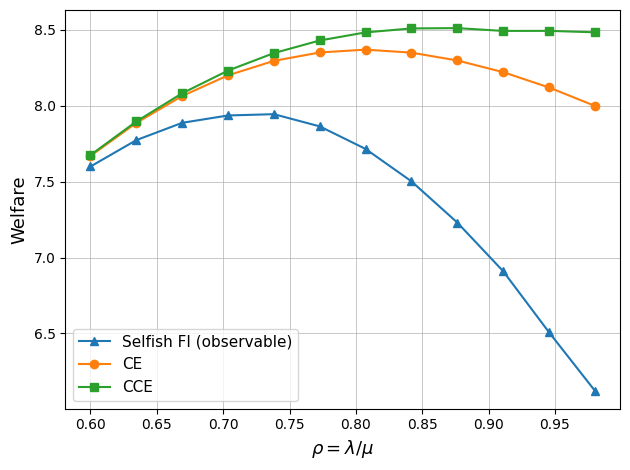

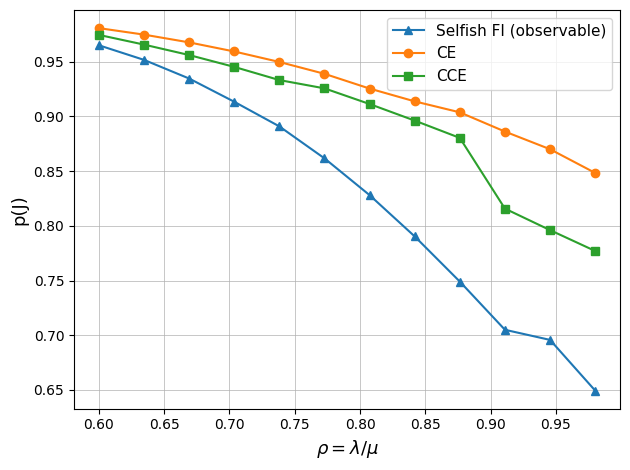

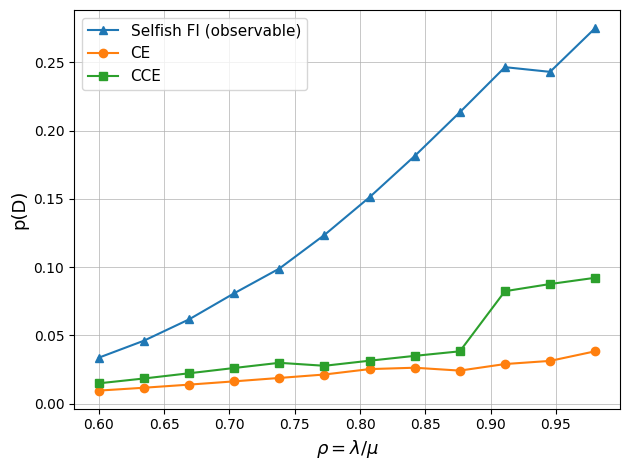

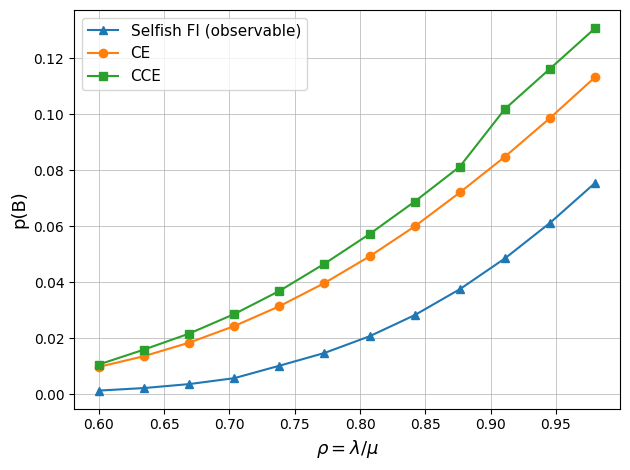

In [4]:
rho_grid = np.linspace(0.6, 0.98, 12)

def params_at_rho(rho):
    return {"lam": float(rho * mu)}

run_sweep(
    rho_grid, 
    params_at_rho, 
    xlabel=r"$\rho=\lambda/\mu$",
    base_params=base_params, 
    N=N, 
    M=M
)

## Experiment 3: Sensitivity to Callback Intensity γ

Vary the callback trigger intensity γ from 0.05 to 0.80.

$\gamma$=0.05 | welfare FI/CE/CCE = 7.4155 / 8.3258 / 8.3790
$\gamma$=0.1182 | welfare FI/CE/CCE = 6.8166 / 8.2724 / 8.4205
$\gamma$=0.1864 | welfare FI/CE/CCE = 6.7868 / 8.2495 / 8.4558
$\gamma$=0.2545 | welfare FI/CE/CCE = 6.8161 / 8.2505 / 8.4699
$\gamma$=0.3227 | welfare FI/CE/CCE = 6.8246 / 8.2474 / 8.4787
$\gamma$=0.3909 | welfare FI/CE/CCE = 6.8417 / 8.2467 / 8.4850
$\gamma$=0.4591 | welfare FI/CE/CCE = 6.8352 / 8.2469 / 8.4889
$\gamma$=0.5273 | welfare FI/CE/CCE = 6.9103 / 8.2464 / 8.4919
$\gamma$=0.5955 | welfare FI/CE/CCE = 6.9238 / 8.2468 / 8.4941
$\gamma$=0.6636 | welfare FI/CE/CCE = 6.9095 / 8.2472 / 8.4961
$\gamma$=0.7318 | welfare FI/CE/CCE = 6.8973 / 8.2474 / 8.4976
$\gamma$=0.8 | welfare FI/CE/CCE = 7.0160 / 8.2468 / 8.4993


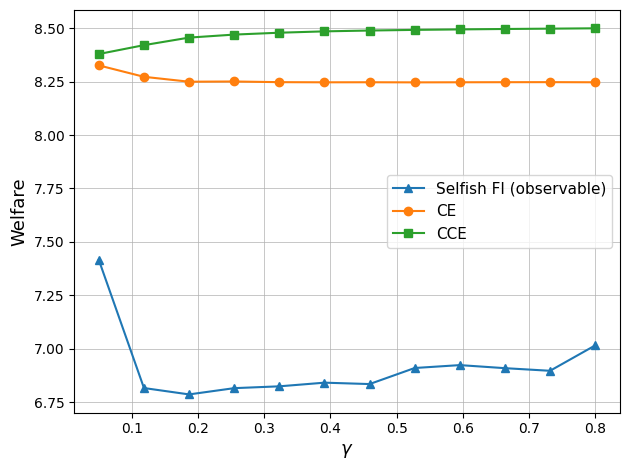

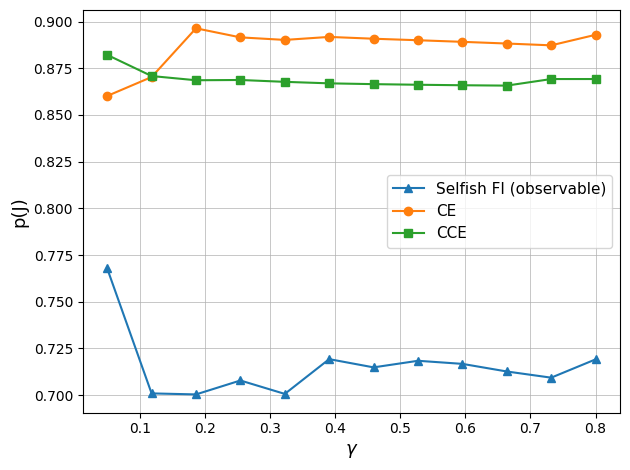

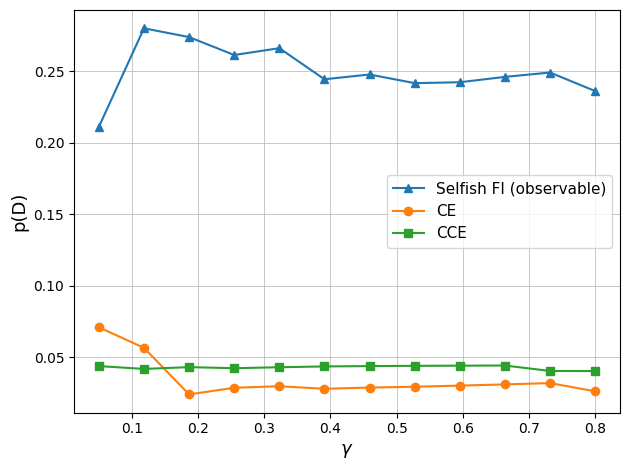

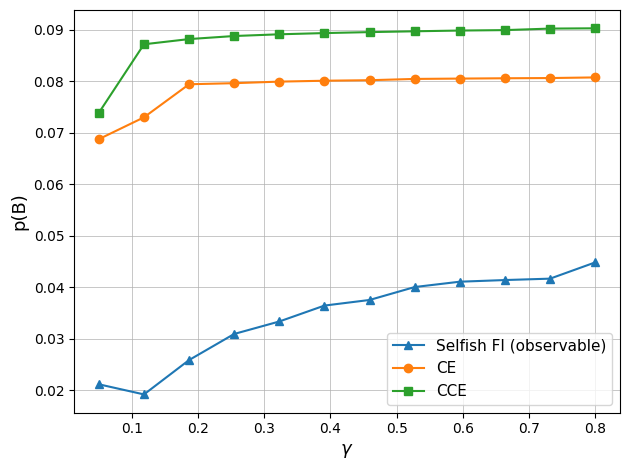

In [6]:
gamma_grid = np.linspace(0.05, 0.80, 12)

def params_at_gamma(gam):
    return {"lam": float(0.90 * mu), "gamma": float(gam)}

run_sweep(
    gamma_grid, 
    params_at_gamma, 
    xlabel=r"$\gamma$",
    base_params=base_params, 
    N=N, 
    M=M
)